# Exploratory Data Analysis (EDA) of a Forest Cover Type Dataset
This notebook conducts exploratory data analysis of the Forest Cover Type multiclass classification dataset `covtype.data` in `dataset_covertype` folder

# Execution steps:
0. Notebook configurations (technical)
1. Loading the `covtype.data` file with correct column names
2. Checking dataset shape and schema
3. Checking missing-value and duplicates
4. Analysis of target class imbalance
5. Continuous feature summary and distributions
6. Feature Analysis of binary wilderness and soil-type
7. Correlation analysis
8. Sampled / stratified sampling of 20,000 rows
9. Comparisson of Original-vs-Sampled (stratified) datasets
10. Saving Sampled dataset

_Note*: EDA evidence is used to justify sampling, metrics, preprocessing, and later model behaviour_

## 0. Notebook configurations (technical)

In [29]:
# if needed, install dependencies from a terminal using startup_script.sh
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# readability improvement for plots
plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams["axes.grid"] = True

# Output & Path folders
DATA_PATH = Path("dataset_covertype/covtype.data")
FIG_DIR = Path("output_figures") / "eda_dataset_original"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR = Path("output_data") / "eda_dataset_original"
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Loading Original Dataset

In [30]:
# checking for loading erros + validation
print(f"Using data path: {DATA_PATH.resolve() if DATA_PATH.exists() else DATA_PATH}")
print(f"File exists: {DATA_PATH.exists()}")
if DATA_PATH.exists():
    print(f"File size: {DATA_PATH.stat().st_size / (1024**2):.2f} MB")

Using data path: /home/vision/Documents/cs_7641_ml/Assignments/ol-report/dataset_covertype/covtype.data
File exists: True
File size: 71.69 MB


In [31]:
# setting column names and groupping features

continuous_cols = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]

wilderness_cols = [f"Wilderness_Area_{i}" for i in range(1, 5)]
soil_cols = [f"Soil_Type_{i}" for i in range(1, 41)]
binary_cols = wilderness_cols + soil_cols
target_col = "Cover_Type"

columns = continuous_cols + wilderness_cols + soil_cols + [target_col]

len(columns), len(continuous_cols), len(binary_cols)

(55, 10, 44)

In [32]:
# setting dataframe

df = pd.read_csv(DATA_PATH, header=None, names=columns)

print("Dataset loaded successfully!!!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!!!
Shape: (581012, 55)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Wilderness_Area_4,Soil_Type_1,Soil_Type_2,Soil_Type_3,Soil_Type_4,Soil_Type_5,Soil_Type_6,Soil_Type_7,Soil_Type_8,Soil_Type_9,Soil_Type_10,Soil_Type_11,Soil_Type_12,Soil_Type_13,Soil_Type_14,Soil_Type_15,Soil_Type_16,Soil_Type_17,Soil_Type_18,Soil_Type_19,Soil_Type_20,Soil_Type_21,Soil_Type_22,Soil_Type_23,Soil_Type_24,Soil_Type_25,Soil_Type_26,Soil_Type_27,Soil_Type_28,Soil_Type_29,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5


# 2. Checking dataset shape and schema

In [33]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Input features:", df.shape[1] - 1)
print("Target column:", target_col)

Rows: 581012
Columns: 55
Input features: 54
Target column: Cover_Type


In [34]:
# checking memory usage
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area_1                   581012 non-null  int64
 11  Wilderness_Area_2                   581012 non-null  int64
 12 

In [35]:
# checking missing and duplicate values

missing_total = df.isna().sum().sum()
duplicate_total = df.duplicated().sum()

summary_check = pd.DataFrame({
    "Check": ["Missing values", "Duplicate rows", "Number of classes"],
    "Value": [missing_total, duplicate_total, df[target_col].nunique()]
})
summary_check.to_csv(OUT_DIR / "summary_check.csv", index=False)
summary_check

,Check,Value
0,Missing values,0
1,Duplicate rows,0
2,Number of classes,7


In [36]:
# Validate binary columns: they should contain only 0/1 values.
binary_validity = pd.DataFrame({
    "column": binary_cols,
    "unique_values": [sorted(df[c].unique().tolist()) for c in binary_cols],
    "is_binary_0_1": [set(df[c].unique()).issubset({0, 1}) for c in binary_cols]
})

binary_validity[~binary_validity["is_binary_0_1"]].head()

,column,unique_values,is_binary_0_1


# 3. Checking missing-value and duplicates

In [37]:
class_counts = df[target_col].value_counts().sort_index()
class_pct = df[target_col].value_counts(normalize=True).sort_index() * 100

class_distribution = pd.DataFrame({
    "class_count": class_counts,
    "class_percent": class_pct.round(3)
})
class_distribution.to_csv(OUT_DIR / "class_distribution.csv", index=False)
class_distribution

,class_count,class_percent
Cover_Type,,
1,211840,36.461
2,283301,48.760
3,35754,6.154
4,2747,0.473
5,9493,1.634
6,17367,2.989
7,20510,3.530


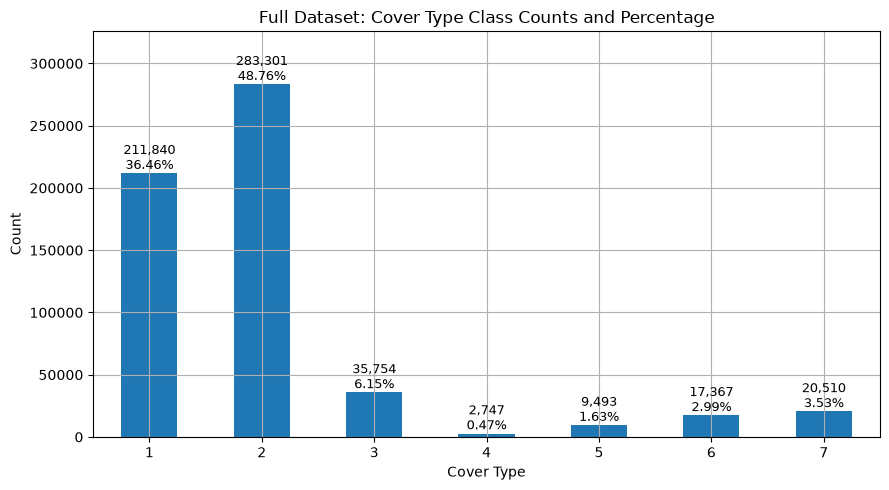

In [38]:
# plotting the data assesment with combined percentages and counts in a single chart

class_summary = (
    pd.DataFrame({
        "Count": class_counts,
        "Percent": class_pct
    })
    .sort_index()
)

ax = class_summary["Count"].plot(kind="bar", figsize=(9,5))

ax.set_title("Full Dataset: Cover Type Class Counts and Percentage")
ax.set_xlabel("Cover Type")
ax.set_ylabel("Count")
plt.xticks(rotation=0)

# adding count and percent labels above each bar
for i, (cover_type, row) in enumerate(class_summary.iterrows()):
    count = int(row["Count"])
    percent = row["Percent"]

    ax.text(
        i,
        count,
        f"{count:,}\n{percent:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

# adding headroom for labels fit
ax.set_ylim(0, class_summary["Count"].max() * 1.15)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_cover_type_class_counts_and_percentage.png", dpi=160, bbox_inches="tight")
plt.show()

### Initial assessment of the dataset

The target distribution has an obvious class imbalane. Cover Type 1 and 2 are most represented in the dataset, with Class 2 of 48.76%, and Class 1 with about 36.46%. Classes 4,5,6 and 7 comparatively rate, with Class 4 being especially underrepresented.

It might suggest that accurace may overstate model quliaty because a classifier can achieve strong overall acuracy by correctly predicting the majority classes while still performing poorly on minority classes.

Later evaluation should include macro-F1 and cnfousion matrices. Macro-F1 gives equal weight to each class and is more sensitive to minority-class errors, while confusion matrices revela which cover types are systematically misclassified

# 4. Analysis of target class imbalance

Checking numeric feature values distrubution - continuous cartographic features. Would crucial for later understanding of scale, spread, outliers, and whether scaling is needed for kNN, CVM, and neural networks

In [39]:
continuous_summary = df[continuous_cols].describe().T
continuous_summary.to_csv(OUT_DIR / "continuous_summary.csv", index=False)
continuous_summary

,count,mean,std,min,25%,50%,75%,max
Elevation,581012.0,2959.365301,279.984734,1859.0,2809.0,2996.0,3163.0,3858.0
Aspect,581012.0,155.656807,111.913721,0.0,58.0,127.0,260.0,360.0
Slope,581012.0,14.103704,7.488242,0.0,9.0,13.0,18.0,66.0
Horizontal_Distance_To_Hydrology,581012.0,269.428217,212.549356,0.0,108.0,218.0,384.0,1397.0
Vertical_Distance_To_Hydrology,581012.0,46.418855,58.295232,-173.0,7.0,30.0,69.0,601.0
Horizontal_Distance_To_Roadways,581012.0,2350.146611,1559.254870,0.0,1106.0,1997.0,3328.0,7117.0
Hillshade_9am,581012.0,212.146049,26.769889,0.0,198.0,218.0,231.0,254.0
Hillshade_Noon,581012.0,223.318716,19.768697,0.0,213.0,226.0,237.0,254.0
Hillshade_3pm,581012.0,142.528263,38.274529,0.0,119.0,143.0,168.0,254.0
Horizontal_Distance_To_Fire_Points,581012.0,1980.291226,1324.195210,0.0,1024.0,1710.0,2550.0,7173.0


In [40]:
# addiontal diagnostics for extra spread
continuous_summary_extra = df[continuous_cols].agg(["mean", "std", "min", "median", "max"]).T
continuous_summary_extra["range"] = continuous_summary_extra["max"] = continuous_summary_extra["min"]
continuous_summary_extra.sort_values("range", ascending=False)
continuous_summary_extra.to_csv(OUT_DIR / "continuous_summary_extra.csv", index=False)

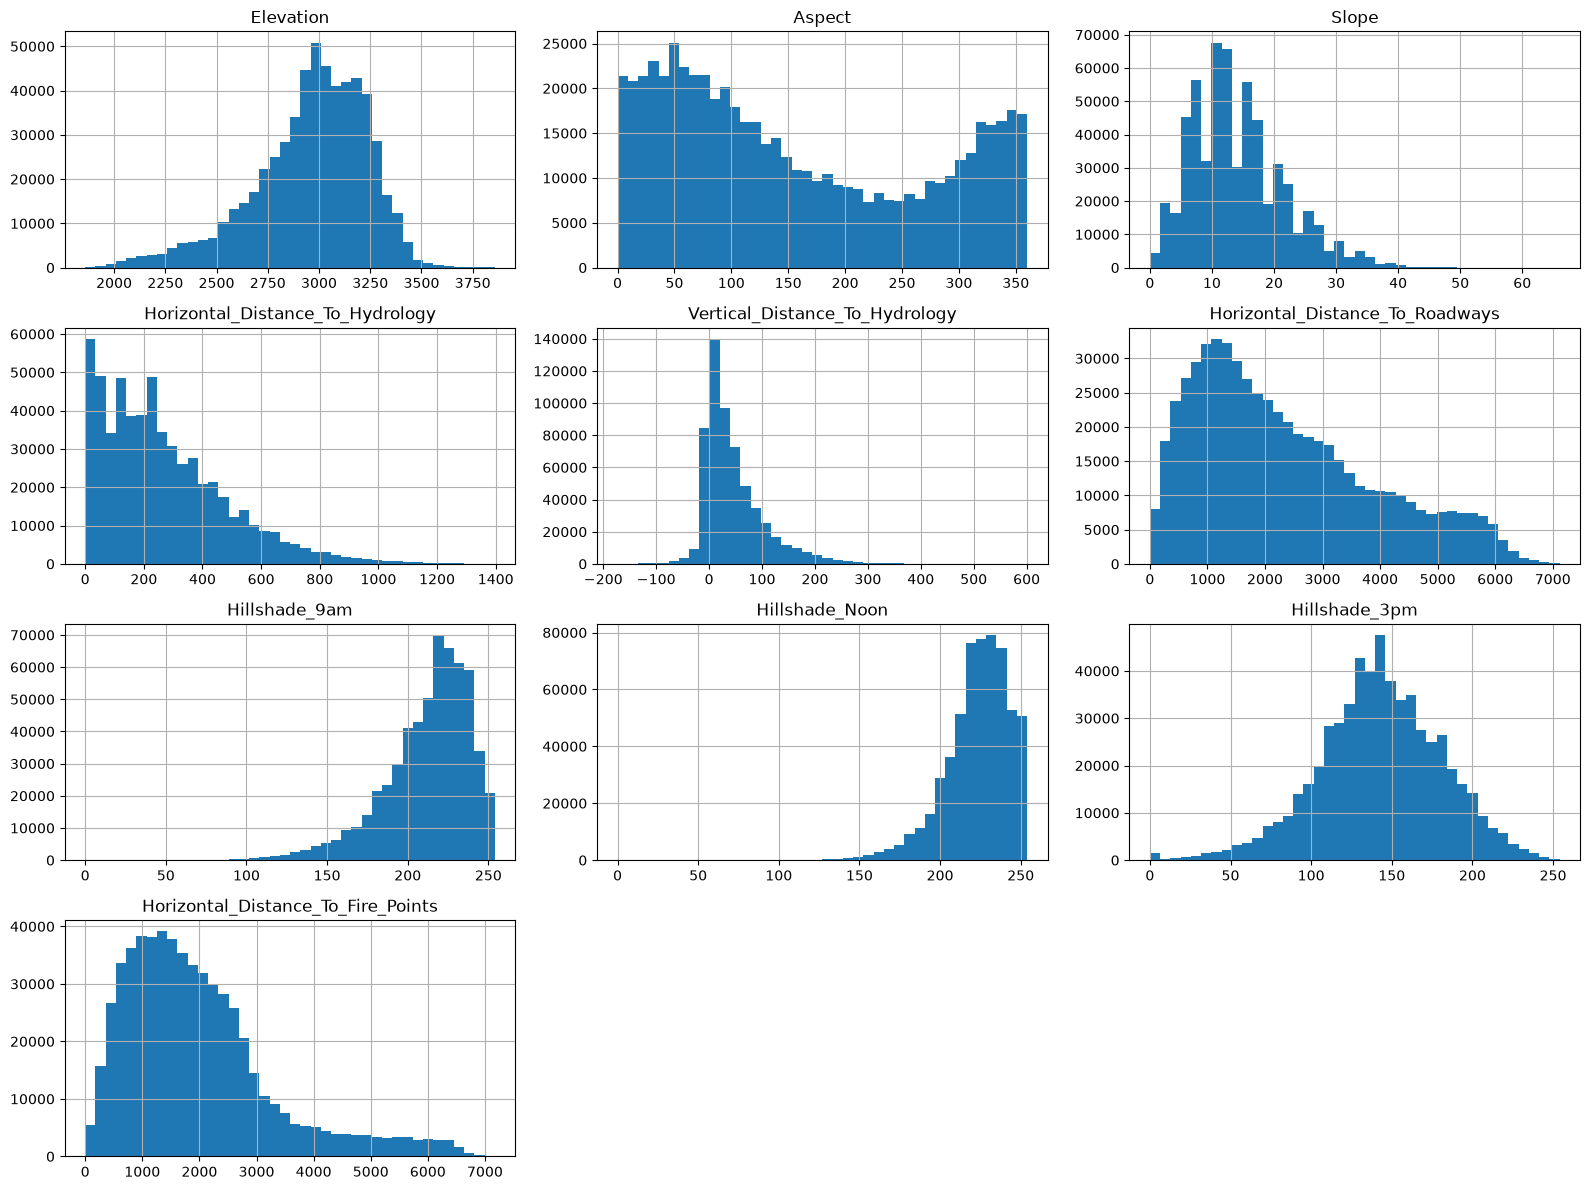

In [41]:
# plotting histograms for continuous features.
df[continuous_cols].hist(bins=40, figsize=(16, 12))
plt.tight_layout()
plt.savefig(FIG_DIR / "02_histograms_for_continuous_features.png", dpi=160, bbox_inches="tight")
plt.show()

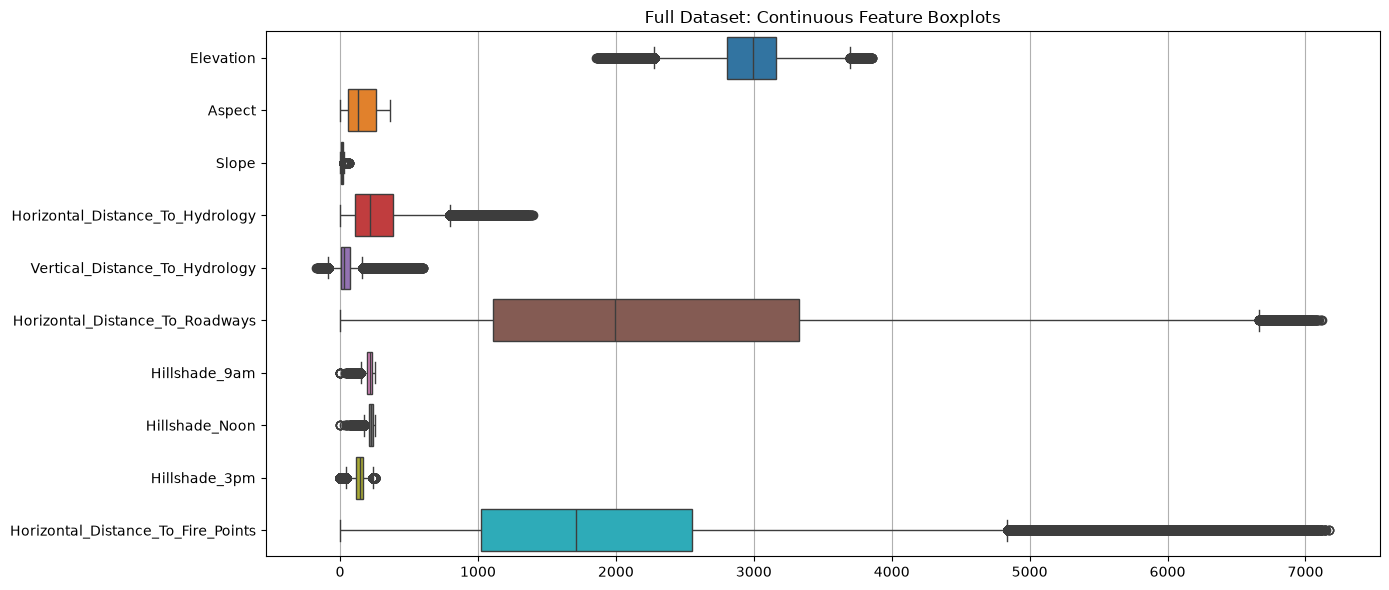

In [42]:
# Inspecting spread nad potential outliers with boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[continuous_cols], orient="h")
plt.title("Full Dataset: Continuous Feature Boxplots")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_spread_and_outliers.png", dpi=160, bbox_inches="tight")
plt.show()

# 5. Continuous feature summary and distributions
Explanation search for features separing forest cover types

In [43]:
class_feature_means = df.groupby(target_col)[continuous_cols].mean().round(2)
class_feature_means.to_csv(OUT_DIR / "class_feature_means.csv", index=False)
class_feature_means

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
Cover_Type,,,,,,,,,,
1,3128.64,156.14,13.13,270.56,42.16,2614.83,212.00,223.43,143.88,2009.25
2,2920.94,152.06,13.55,279.92,45.88,2429.53,213.84,225.33,142.98,2168.15
3,2394.51,176.37,20.77,210.28,62.45,943.94,201.92,215.83,140.37,910.96
4,2223.94,137.14,18.53,106.93,41.19,914.20,228.35,217.00,111.39,859.12
5,2787.42,139.28,16.64,212.35,50.61,1349.77,223.47,219.04,121.92,1577.72
6,2419.18,180.54,19.05,159.85,45.44,1037.17,192.84,209.83,148.28,1055.35
7,3361.93,153.24,14.26,356.99,69.47,2738.25,216.97,221.75,134.93,2070.03


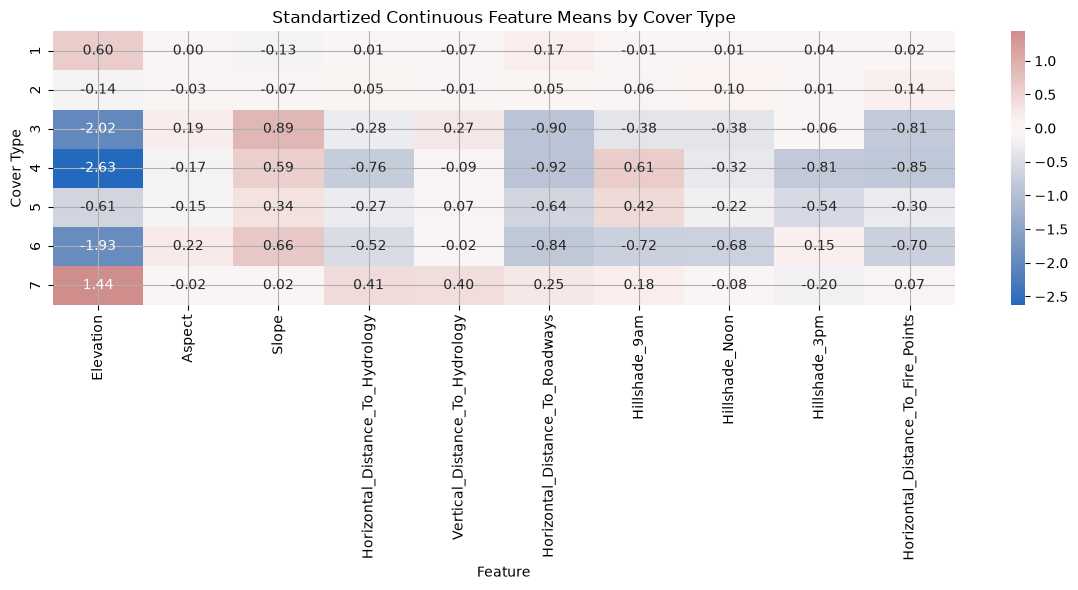

In [44]:
# Heatmap of class feature means after simple standartization for visuzliation only
standartized_class_means = class_feature_means.copy()
standartized_class_means = (standartized_class_means - df[continuous_cols].mean()) / df[continuous_cols].std()

plt.figure(figsize=(12, 6))
sns.heatmap(standartized_class_means, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Standartized Continuous Feature Means by Cover Type")
plt.xlabel("Feature")
plt.ylabel("Cover Type")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_Standartized_Continuous_Feature Means_by_Cover_Type.png", dpi=160, bbox_inches="tight")
plt.show()    

# 6. Feature Analysis of binary wilderness and soil-type

The Original dataset has many binary indicator features. For each row, wilderness area and soil type are represented using one-hot encoded columns. Sections checks how common or rare those indicators are.

In [45]:
wilderness_counts = df[wilderness_cols].sum().sort_values(ascending=False)
wilderness_pct = wilderness_counts / len(df) * 100

wilderness_distribution = pd.DataFrame({
    "count": wilderness_counts,
    "percent": wilderness_pct.round(3)
})
wilderness_distribution.to_csv(OUT_DIR / "wilderness_distribution.csv", index=False)
wilderness_distribution

,count,percent
Wilderness_Area_1,260796,44.887
Wilderness_Area_3,253364,43.607
Wilderness_Area_4,36968,6.363
Wilderness_Area_2,29884,5.143


<function matplotlib.pyplot.show(close=None, block=None)>

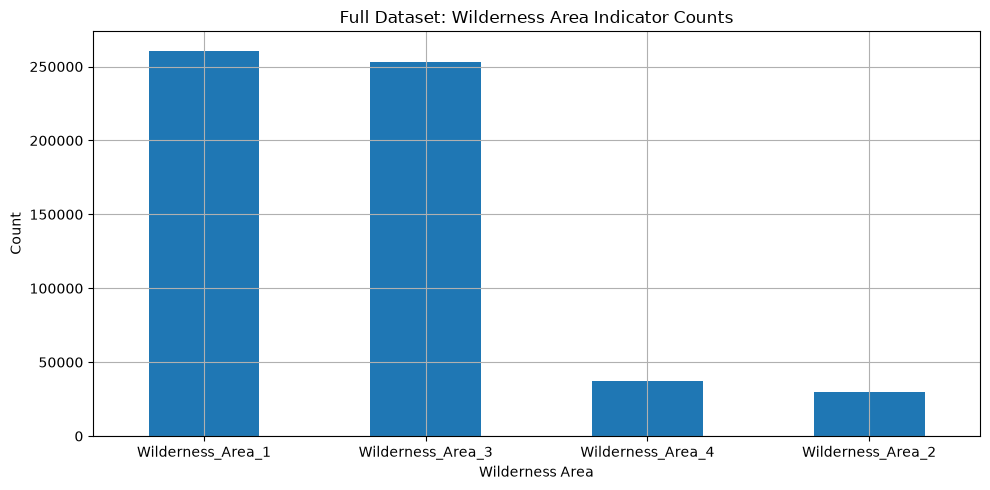

In [46]:
ax = wilderness_counts.plot(kind="bar")
ax.set_title("Full Dataset: Wilderness Area Indicator Counts")
ax.set_xlabel("Wilderness Area")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_Wilderness_Area_Indicator_Counts_dataset.png", dpi=160, bbox_inches="tight")
plt.show

In [47]:
soil_counts = df[soil_cols].sum().sort_values(ascending=False)
soil_pct = soil_counts / len(df) * 100

soil_distribution = pd.DataFrame({
    "count": soil_counts,
    "percent": soil_pct.round(3)
})
soil_distribution.to_csv(OUT_DIR / "soil_distribution.csv", index=False)
soil_distribution.head(15)

,count,percent
Soil_Type_29,115247,19.836
Soil_Type_23,57752,9.940
Soil_Type_32,52519,9.039
Soil_Type_33,45154,7.772
Soil_Type_22,33373,5.744
Soil_Type_10,32634,5.617
Soil_Type_30,30170,5.193
Soil_Type_12,29971,5.158
Soil_Type_31,25666,4.417
Soil_Type_24,21278,3.662


<function matplotlib.pyplot.show(close=None, block=None)>

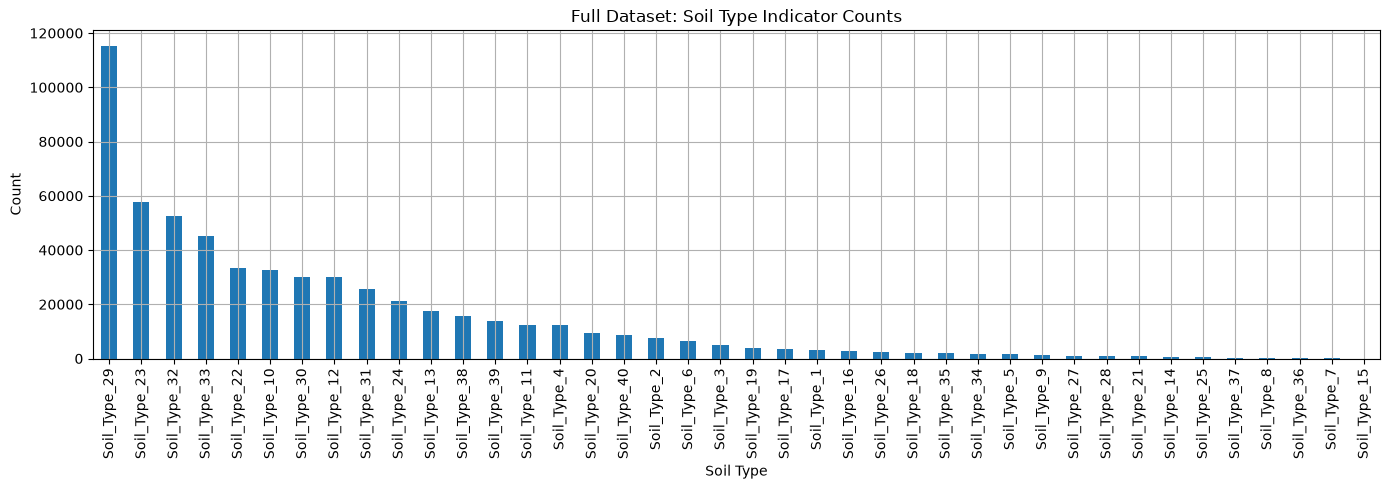

In [48]:
plt.figure(figsize=(14, 5))
soil_counts.plot(kind="bar")
plt.title("Full Dataset: Soil Type Indicator Counts")
plt.xlabel("Soil Type")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_Full_Dataset_Soil_Type_Indicator_Counts.png", dpi=160, bbox_inches="tight")
plt.show

In [49]:
rare_soil_types = soil_distribution[soil_distribution["percent"] < 1.0]
rare_soil_types.to_csv(OUT_DIR / "rare_soil_types.csv", index=False)
rare_soil_types

,count,percent
Soil_Type_3,4823,0.830
Soil_Type_19,4021,0.692
Soil_Type_17,3422,0.589
Soil_Type_1,3031,0.522
Soil_Type_16,2845,0.490
Soil_Type_26,2589,0.446
Soil_Type_18,1899,0.327
Soil_Type_35,1891,0.325
Soil_Type_34,1611,0.277
Soil_Type_5,1597,0.275


In [50]:
# Checking each row because it should have exactly one wilderness are and one wilderness area type active
one_of_two_checks = pd.DataFrame({
    "wilderness_active_count": df[wilderness_cols].sum(axis=1).value_counts().sort_index(),
    "soil_active_count": df[soil_cols].sum(axis=1).value_counts().sort_index(),
})
one_of_two_checks.to_csv(OUT_DIR / "one_of_two_checks.csv", index=False)
one_of_two_checks

print("Rows with exactly one wilderness area:", (df[wilderness_cols].sum(axis=1) == 1).mean() * 100, "%")
print("Rows with exactly one soil type:", (df[soil_cols].sum(axis=1) == 1).mean() * 100, "%")

Rows with exactly one wilderness area: 100.0 %
Rows with exactly one soil type: 100.0 %


# 7. Correlation analysis
Correlation is most meaningful for the continuous features. The one_of_two columns are better analyzed through frequencies and class relationship

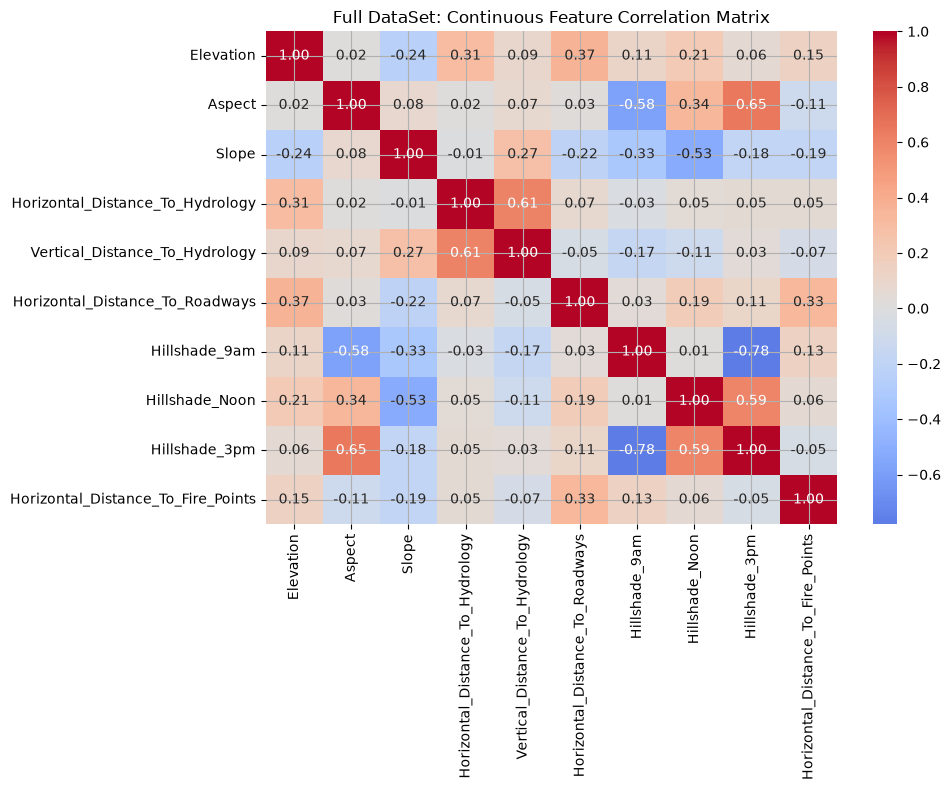

In [51]:
continuous_corr = df[continuous_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(continuous_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Full DataSet: Continuous Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_Full_DataSet_Continuous_Feature_Correlation_Matrix.png", dpi=160, bbox_inches="tight")
plt.show()

In [52]:
# listing strongest absolute correlations, excluding self-correlation
corr_pairs = (
    continuous_corr
    .where(np.triu(np.ones(continuous_corr.shape), k=1).astype(bool))
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)

corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()
corr_pairs.sort_values("abs_correlation", ascending=False).head(10)
corr_pairs.to_csv(OUT_DIR / "correlation_pairs.csv", index=False)

# 8 Sampled / stratified sampling of 20,000 rows
20K instances from the full dataset are needed for the training. Because the target classes are terrible imbalanced, a stratified dataset is the safest option. This would preserve the class proportions of the full dataset that will minimize impact on training and testing results

Full dataset shape: (581012, 55)
Sample shape: (20000, 55)
Remainder shape: (561012, 55)


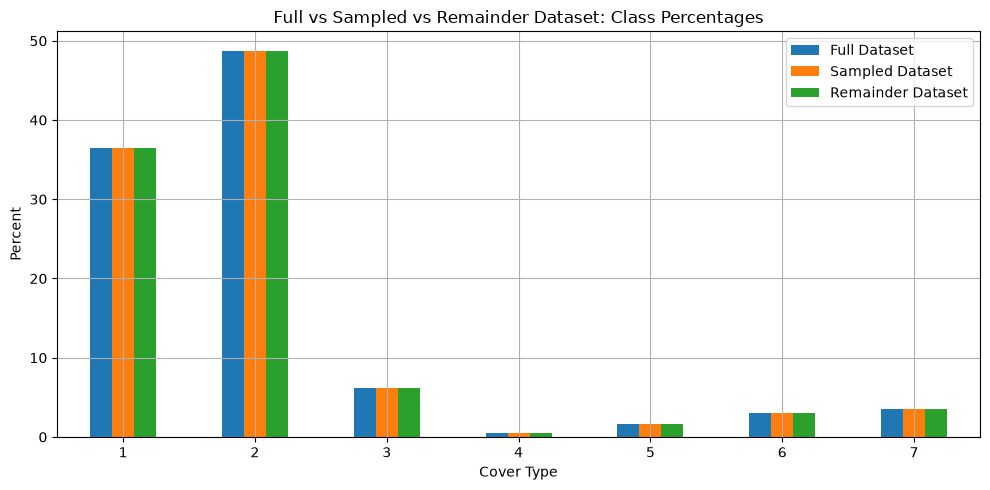

In [53]:
SAMPLE_SIZE = 20_000
RANDOM_STATE = 42

sample_df, remainder_df = train_test_split(
    df,
    train_size=SAMPLE_SIZE,
    stratify=df[target_col],
    random_state=RANDOM_STATE,
)

# resetting indexes for cleaner downstream work
sample_df = sample_df.reset_index(drop=True)
remainder_df = remainder_df.reset_index(drop=True)

print("Full dataset shape:", df.shape)
print("Sample shape:", sample_df.shape)
print("Remainder shape:", remainder_df.shape)



# comparing sistribution
sample_class_counts = sample_df[target_col].value_counts().sort_index()
sample_class_pct = sample_df[target_col].value_counts(normalize=True).sort_index() * 100

remainder_class_counts = remainder_df[target_col].value_counts().sort_index()
remainder_class_pct = remainder_df[target_col].value_counts(normalize=True).sort_index() * 100

sample_class_distribution = pd.DataFrame({
    "full_count": class_counts,
    "full_percent": class_pct.round(3),
    "sample_ount": sample_class_counts,
    "sample_percent": sample_class_pct.round(3),
    "remainder_count": remainder_class_counts,
    "remainder_percent": remainder_class_pct.round(3),
})

sample_class_distribution["sample_percent_difference"] = (
    sample_class_distribution["sample_percent"]
    - sample_class_distribution["full_percent"]
).round(3)

sample_class_distribution["remainder_percent_difference"] = (
    sample_class_distribution["remainder_percent"]
    - sample_class_distribution["full_percent"]
).round(3)

sample_class_distribution.to_csv(OUT_DIR / "sample_class_distribution.csv", index=False)
sample_class_distribution

# plotting distribution comparisson chart visualizaiton
comparison_pct = pd.DataFrame({
    "Full Dataset": class_pct,
    "Sampled Dataset": sample_class_pct,
    "Remainder Dataset": remainder_class_pct,
})

ax = comparison_pct.plot(kind="bar", figsize=(10, 5))

ax.set_title("Full vs Sampled vs Remainder Dataset: Class Percentages")
ax.set_xlabel("Cover Type")
ax.set_ylabel("Percent")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "08_Full_Sampled_Remainder_Dataset_Class_Percentages", dpi=160, bbox_inches="tight")
plt.show()

# 9. Comparisson of Original-vs-Sampled (stratified) datasets
Comparisson whether the sampled dataset has similar continuous-feature means and standard deviations to the full dataset

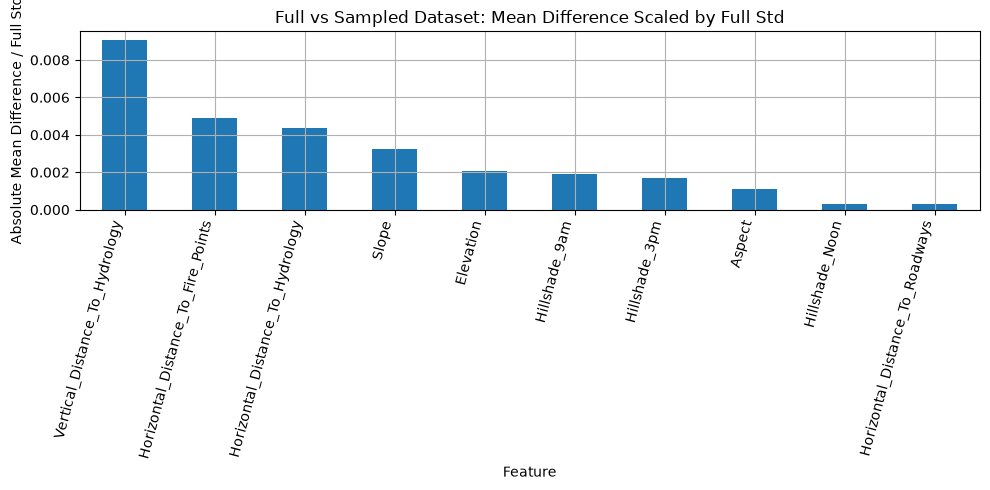

In [54]:
full_means = df[continuous_cols].mean()
sample_means = sample_df[continuous_cols].mean()
full_stds = df[continuous_cols].std()
sample_stds = sample_df[continuous_cols].std()

feature_comparison = pd.DataFrame({
    "full_mean": full_means,
    "sample_mean": sample_means,
    "mean_abs_diff": (sample_means - full_means).abs(),
    "full_std": full_stds,
    "sample_std": sample_stds,
    "stb_abd_diff": (sample_stds - full_stds).abs(),
})

feature_comparison.round(3)
feature_comparison.to_csv(OUT_DIR / "feature_comparison.csv", index=False)

# plotting mean differences as percentages of full standard deviation
mean_diff_scaled = ((sample_means - full_means).abs() / full_stds).sort_values(ascending=False)

ax = mean_diff_scaled.plot(kind="bar")
ax.set_title("Full vs Sampled Dataset: Mean Difference Scaled by Full Std")
ax.set_xlabel("Feature")
ax.set_ylabel("Absolute Mean Difference / Full Std")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "09_Full_vs_Sampled_Dataset_Mean_Difference_Scaled", dpi=160, bbox_inches="tight")
plt.show()

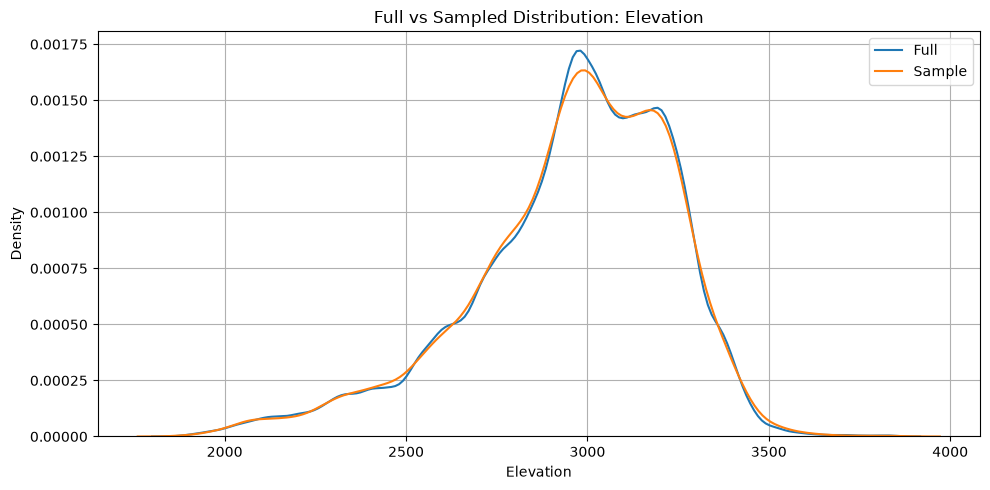

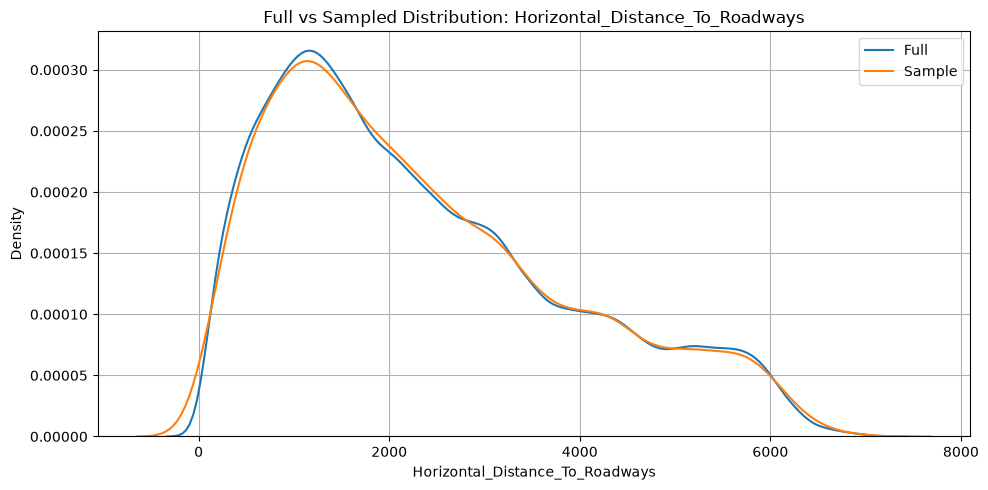

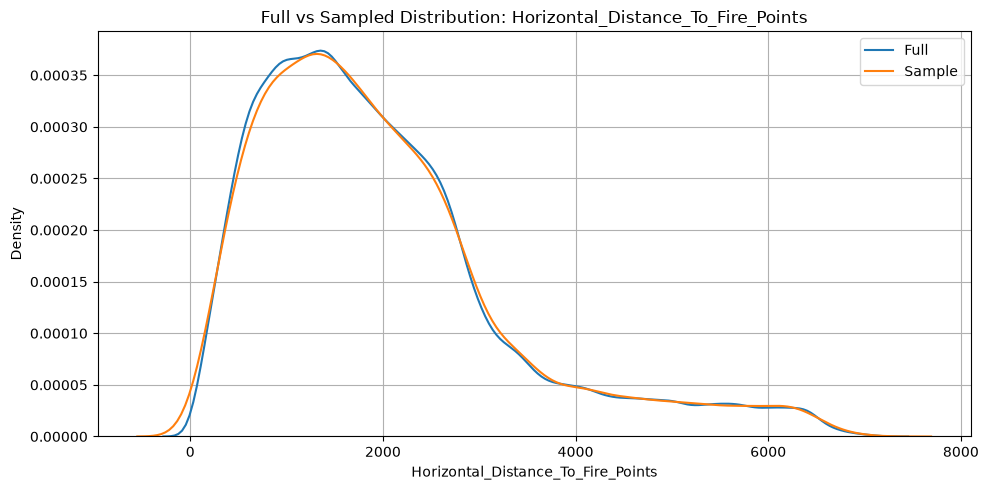

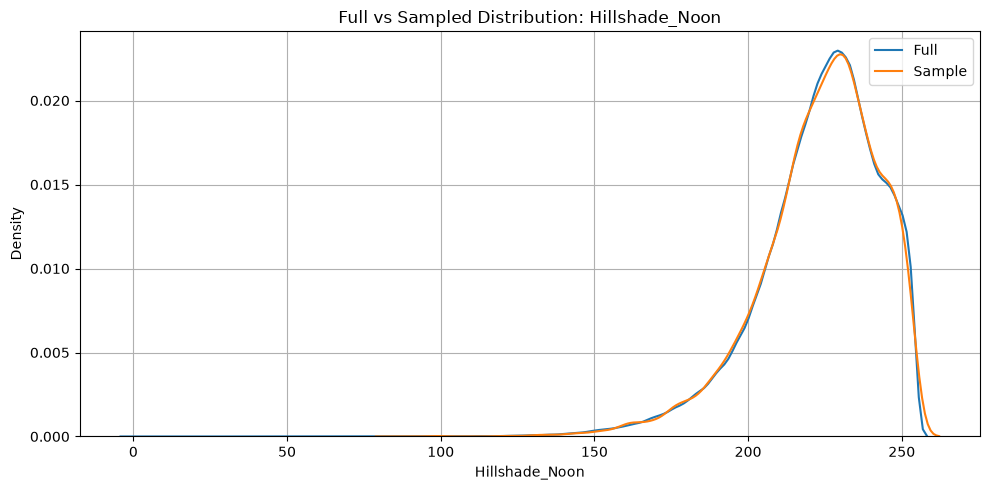

In [55]:
#overlay distribution for a few important continuous features
features_to_compare = [
    "Elevation",
    "Horizontal_Distance_To_Roadways",
    "Horizontal_Distance_To_Fire_Points",
    "Hillshade_Noon",
]

for col in features_to_compare:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(df[col], label="Full", fill=False)
    sns.kdeplot(sample_df[col], label="Sample", fill=False)
    plt.title(f"Full vs Sampled Distribution: {col}")
    plt.xlabel(col)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "10_Full_vs_Sampled_Distribution_by_columns", dpi=160, bbox_inches="tight")
    plt.show()

# 11. Saving Sampled dataset

In [56]:
sample_df.to_csv(OUT_DIR / "dataset_stratified.csv", index=False)
remainder_df.to_csv(OUT_DIR / "dataset_remainder.csv", index=False)

print(f"Saved sample dataset to: {OUT_DIR}")
print(f"Saved remainder dataset to: {OUT_DIR}")

Saved sample dataset to: output_data/eda_dataset_original
Saved remainder dataset to: output_data/eda_dataset_original
